## 1. 데이터 로드하기
### 1.1 데이터 다운로드

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

### 1.2 데이터 확인 및 전처리

(70000, 784)
int64
(70000,)
5
<class 'str'>


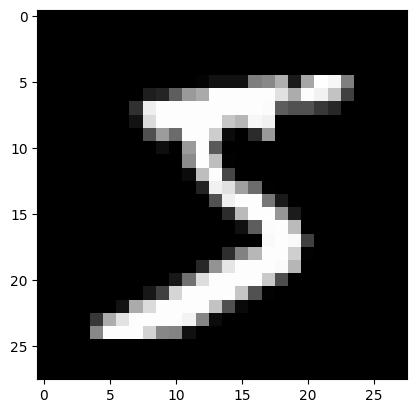

In [2]:
print(mnist.data.shape)
print(mnist.data.dtype)
plt.imshow(mnist.data[0].reshape(28, 28).astype(np.uint8), cmap='gray')

print(mnist.target.shape)
print(mnist.target[0])
print(type(mnist.target[0]))

### 1.3 데이터 적재하기

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(
    mnist.data.astype(np.float32) / 255.0,
    mnist.target.astype(np.int8),
    test_size=1/7,
    random_state=0
)

ds_train = TensorDataset(
    torch.tensor(train_x),
    torch.tensor(train_y, dtype=torch.long)
)
ds_test = TensorDataset(
    torch.tensor(test_x),
    torch.tensor(test_y, dtype=torch.long)
)

batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=batch_size)

## 2. 다층 퍼셉트론 분류기
### 2.1 분류기 구현

In [4]:
from torch import nn
from torch import optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = nn.Sequential() # Create an empty sequential model
model.add_module('fc1', nn.Linear(28*28*1, 128))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(128, 128))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(128, 10))

print(model)

Using device: cpu
Sequential(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

### 2.2 분류기 훈련

In [6]:
epochs = 128
losses, accuracies = [], []

for epoch in range(epochs):
    for data, targets in dl_train:
        optimizer.zero_grad()
        output = model(data)
        accuracy = (output.argmax(dim=1) == targets).float().mean()

        loss = loss_fn(output, targets)
        loss.backward()

        optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}')
    
    losses.append(loss.item())
    accuracies.append(accuracy.item())

Epoch 10/128, Loss: 0.0666, Accuracy: 0.9770
Epoch 20/128, Loss: 0.0361, Accuracy: 0.9868
Epoch 30/128, Loss: 0.0186, Accuracy: 0.9951
Epoch 40/128, Loss: 0.0074, Accuracy: 0.9984
Epoch 50/128, Loss: 0.0025, Accuracy: 1.0000
Epoch 60/128, Loss: 0.0007, Accuracy: 1.0000
Epoch 70/128, Loss: 0.0006, Accuracy: 1.0000
Epoch 80/128, Loss: 0.0004, Accuracy: 1.0000
Epoch 90/128, Loss: 0.0002, Accuracy: 1.0000
Epoch 100/128, Loss: 0.0001, Accuracy: 1.0000
Epoch 110/128, Loss: 0.0001, Accuracy: 1.0000
Epoch 120/128, Loss: 0.0000, Accuracy: 1.0000


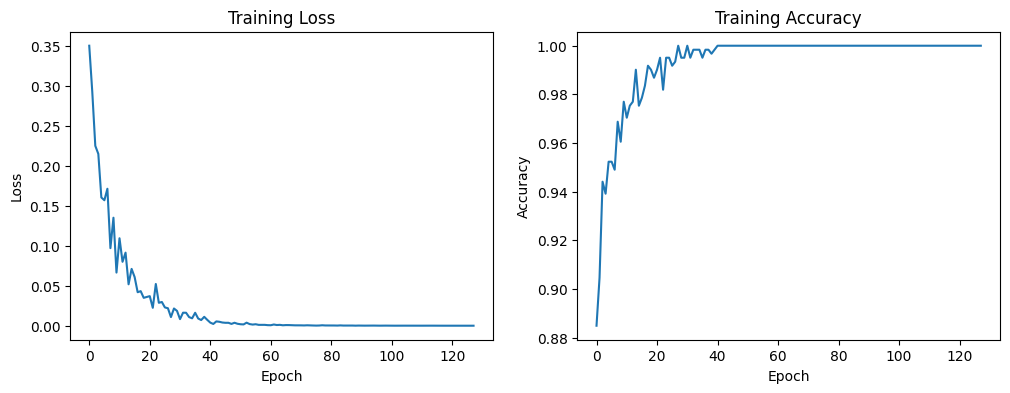

In [7]:
fix, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(accuracies)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.show()

### 2.3 분류기 평가

In [8]:
model.eval() # 모델을 평가 모드로 전환
correct = 0

with torch.no_grad(): # 평가 시에는 기울기 계산을 하지 않음
    for data, targets in dl_test:
        output = model(data)
        predictions = output.argmax(dim=1)
        correct += (predictions == targets).sum().item()

data_size = len(ds_test)
test_accuracy = correct / data_size
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 0.9752


Index: 559, Predicted: 3, Actual: 3


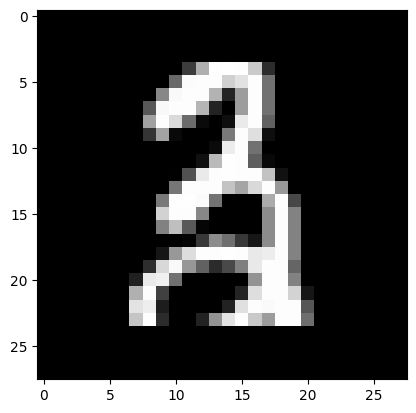

In [21]:
index = np.random.randint(0, 10000)

input = torch.tensor(test_x[index])
output = model(input)
prediction = output.argmax().item()
print(f'Index: {index}, Predicted: {prediction}, Actual: {test_y[index]}')
plt.imshow(input.reshape(28, 28).numpy(), cmap='gray')